# Кластеризация сигналов сцинтилляционного детектора

**Задача:** автоматически разделить 23 479 осциллограмм на три кластера:
- **Класс 0** — один тип частиц (гамма-кванты или нейтроны)
- **Класс 1** — другой тип частиц
- **Класс 2** — аномальные / нераспознанные сигналы

Работа выполнена в парадигме **unsupervised learning**: размеченных данных нет,
только сырые осциллограммы. Из каждого сигнала извлекаются физически
мотивированные признаки (Feature Engineering), после чего сравниваются несколько
алгоритмов кластеризации, выбирается лучший, формируется submission.

**Воспроизводимость:** фиксируем `SEED = 42`.


## 0. Импорты и воспроизводимость

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats, signal as scipy_signal
from scipy.integrate import trapezoid
from scipy.stats import skew, kurtosis

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_selection import VarianceThreshold

import umap.umap_ as umap

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

DATA_PATH = "./Run200_Wave_0_1.txt"
SUBMIT_DIR = "submissions_sinctillator"
import os; os.makedirs(SUBMIT_DIR, exist_ok=True)

p:\maga\2sem\ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Загрузка данных

Каждая строка файла: `byte_offset  event_id  flag  n_samples  w_0 w_1 … w_499`  
Первые 4 поля — метаданные, остальные 500 — АЦП-отсчёты осциллограммы.


In [2]:
raw = pd.read_csv(DATA_PATH, sep=' ', header=None, skipinitialspace=True)
raw = raw.dropna(axis=1, how='all')

meta = raw.iloc[:, :4].copy()
data = raw.iloc[:, 4:504].copy()
data.columns = [f't_{i}' for i in range(data.shape[1])]

waves = data.values.astype(np.float64)
event_ids = data.index.tolist()

In [3]:
print('raw shape:', raw.shape)
print('meta shape:', meta.shape)
print('signal matrix shape:', data.shape)


raw shape: (23479, 504)
meta shape: (23479, 4)
signal matrix shape: (23479, 500)


In [4]:
data.head()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_490,t_491,t_492,t_493,t_494,t_495,t_496,t_497,t_498,t_499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 500 entries, t_0 to t_499
dtypes: int64(500)
memory usage: 89.6 MB


## 2. Исследовательский анализ (EDA)

### 2.1 Примеры осциллограмм — случайная выборка


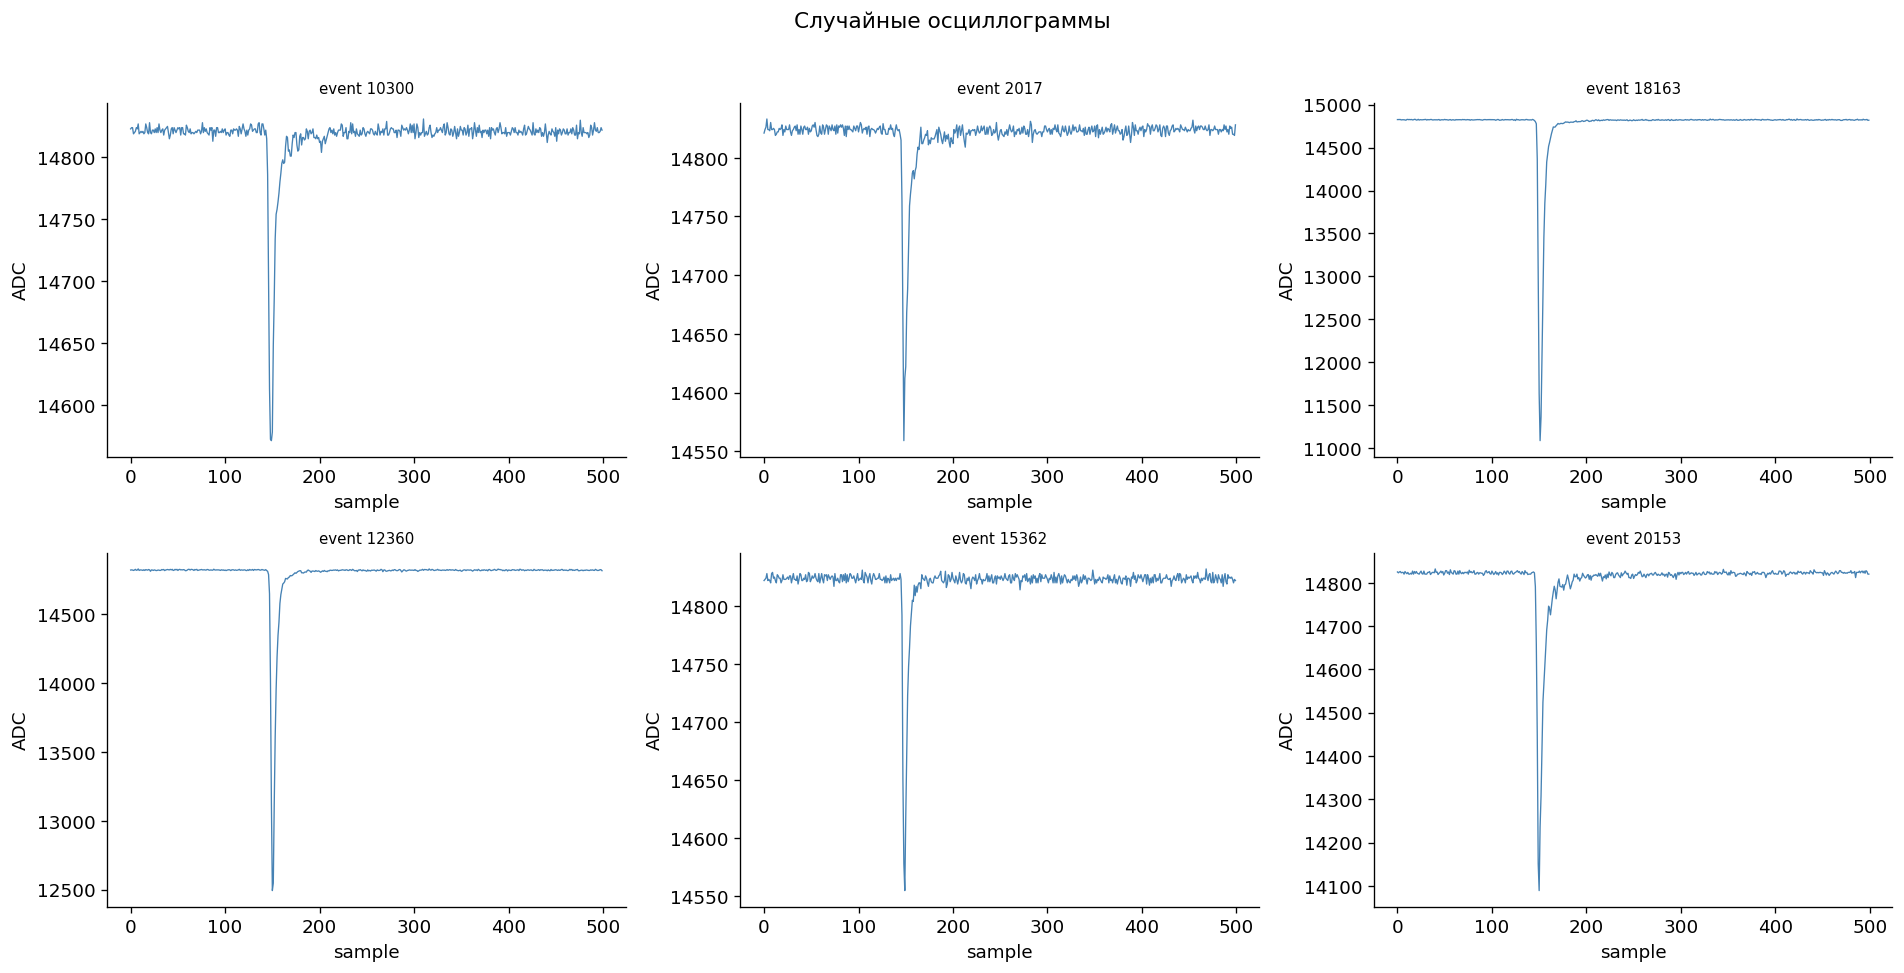

In [6]:
rng = np.random.default_rng(SEED)
idx = rng.choice(len(data), 12, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)
t = np.arange(data.shape[1])

for ax, i in zip(axes.flat, idx):
    row_data = data.iloc[i] 
    
    ax.plot(t, row_data, lw=0.8, color="steelblue")
    ax.set_title(f"event {row_data.name}", fontsize=9) 
    ax.set_xlabel("sample")
    ax.set_ylabel("ADC")

plt.suptitle("Случайные осциллограммы", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("eda_random_waves.png", bbox_inches="tight")
plt.show()

### 2.2 Среднее и дисперсия по времени

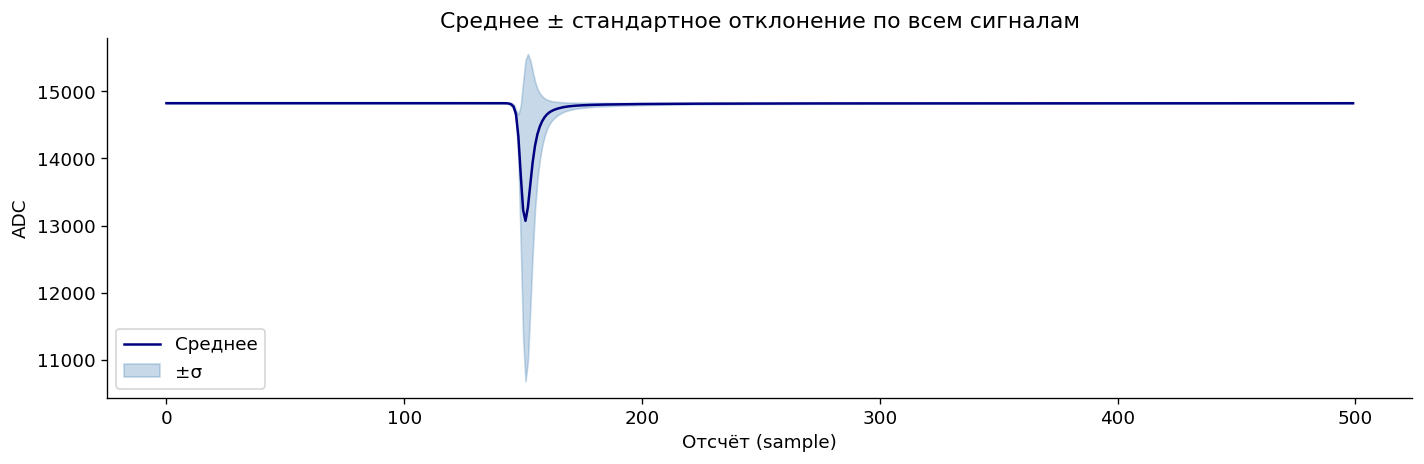

In [7]:
mean_wave = data.mean(axis=0)
std_wave  = data.std(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, mean_wave, label="Среднее", color="navy")
ax.fill_between(t, mean_wave - std_wave, mean_wave + std_wave,
                alpha=0.3, color="steelblue", label="±σ")
ax.set_xlabel("Отсчёт (sample)"); ax.set_ylabel("ADC")
ax.set_title("Среднее ± стандартное отклонение по всем сигналам")
ax.legend(); plt.tight_layout()
plt.savefig("eda_mean_std.png", bbox_inches="tight")
plt.show()

### 2.3 Распределение baseline и амплитуды

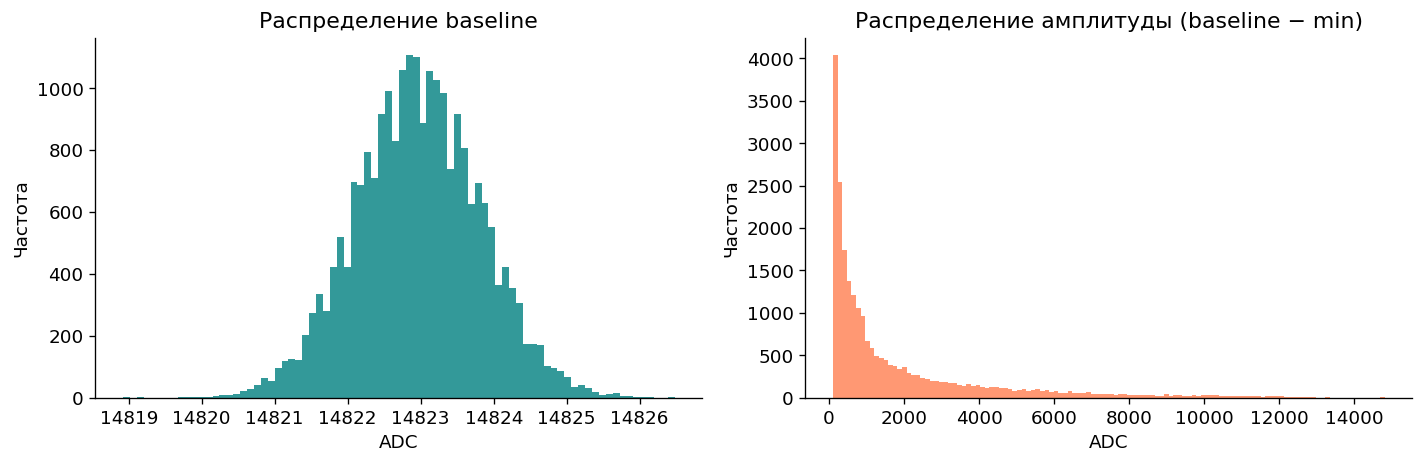

In [8]:
baseline_est = data.iloc[:, :50].mean(axis=1)
amplitude_est = baseline_est - data.iloc[:, :].min(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(baseline_est, bins=80, color="teal", edgecolor="none", alpha=0.8)
axes[0].set_title("Распределение baseline")
axes[0].set_xlabel("ADC"); axes[0].set_ylabel("Частота")

axes[1].hist(amplitude_est, bins=120, color="coral", edgecolor="none", alpha=0.8)
axes[1].set_title("Распределение амплитуды (baseline − min)")
axes[1].set_xlabel("ADC"); axes[1].set_ylabel("Частота")
plt.tight_layout()
plt.savefig("eda_baseline_amp.png", bbox_inches="tight")
plt.show()


## 3. Feature Engineering

Признаки разбиты на группы:
- **Амплитудные** — baseline, амплитуда, нормализованные отсчёты
- **Временны́е** — время нарастания (10–90 %), время спада, ширина на полувысоте (FWHM)
- **Интегральные / PSD** — полный заряд, заряд хвоста (Pulse Shape Discrimination)
- **Статистические** — асимметрия, эксцесс, энтропия формы

PSD (отношение заряда хвоста к полному заряду) — **ключевой** физический дескриптор для n/γ-сепарации в органических сцинтилляторах.


In [9]:
def extract_features(waves, baseline_window=50, tail_start=0.3):
    
    if hasattr(waves, 'values'):
        waves = waves.values.astype(np.float64)
    N, T = waves.shape
    t = np.arange(T)
    feats = {}

    # --- baseline correction ---
    bl = waves[:, :baseline_window].mean(axis=1, keepdims=True)
    w  = bl - waves           # инвертируем: импульс «вверх»
    w  = np.clip(w, 0, None)  # убираем флуктуации до 0

    amp = w.max(axis=1)
    feats["baseline"]  = bl.ravel()
    feats["amplitude"] = amp
    feats["amplitude_log"] = np.log1p(amp)

    # --- temporal ---
    tail_idx = int(T * tail_start)
    q_total = w.sum(axis=1) + 1e-9
    q_tail  = w[:, tail_idx:].sum(axis=1)
    feats["Q_total"]     = q_total
    feats["Q_tail"]      = q_tail
    feats["PSD"]         = q_tail / q_total   # KEY feature

    # rise time 10% → 90%
    norm_w = w / (amp[:, None] + 1e-9)
    rise_10, rise_90, fall_10 = [], [], []
    fwhm_vals, t_peak_vals = [], []

    for i in range(N):
        sig = norm_w[i]
        pk  = sig.argmax()
        t_peak_vals.append(pk)
        # rise
        r10 = np.where(sig[:pk] >= 0.10)[0]
        r90 = np.where(sig[:pk] >= 0.90)[0]
        rise_10.append(r10[0] if len(r10) else pk)
        rise_90.append(r90[0] if len(r90) else pk)
        # fall to 10%
        f10 = np.where(sig[pk:] <= 0.10)[0]
        fall_10.append(f10[0] + pk if len(f10) else T)
        # FWHM
        half = 0.5
        left  = np.where(sig[:pk] >= half)[0]
        right = np.where(sig[pk:] <= half)[0]
        l = left[0]  if len(left)  else pk
        r = right[0] + pk if len(right) else T
        fwhm_vals.append(r - l)

    feats["t_peak"]   = np.array(t_peak_vals)
    feats["rise_10"]  = np.array(rise_10)
    feats["rise_90"]  = np.array(rise_90)
    feats["rise_time"]= np.array(rise_90) - np.array(rise_10)
    feats["fall_time"]= np.array(fall_10) - np.array(t_peak_vals)
    feats["FWHM"]     = np.array(fwhm_vals)

    # --- shape statistics ---
    feats["skewness"]  = skew(w, axis=1)
    feats["kurt"]      = kurtosis(w, axis=1)
    # zero crossings rate (on raw w to catch oscillations/noise)
    diff_sign = np.diff(np.sign(w - w.mean(axis=1, keepdims=True)), axis=1)
    feats["zc_rate"]   = (diff_sign != 0).sum(axis=1) / T

    # RMS
    feats["rms"] = np.sqrt((w**2).mean(axis=1))

    # --- spectral (power in 3 bands) ---
    ps = np.abs(np.fft.rfft(w, axis=1))**2
    B  = ps.shape[1]
    feats["ps_low"]  = ps[:, :B//8].sum(axis=1)
    feats["ps_mid"]  = ps[:, B//8:B//4].sum(axis=1)
    feats["ps_high"] = ps[:, B//4:].sum(axis=1)
    feats["ps_ratio"]= feats["ps_low"] / (feats["ps_high"] + 1e-9)

    # --- ratio features ---
    feats["tail_ratio_50"]  = w[:, T//2:].sum(axis=1)  / (q_total)
    feats["tail_ratio_25"]  = w[:, T//4:].sum(axis=1)  / (q_total)
    feats["head_ratio_10"]  = w[:, :T//10].sum(axis=1) / (q_total)

    return pd.DataFrame(feats)

df_feat = extract_features(data)
print(f"Признаков: {df_feat.shape[1]}")
df_feat.describe().T.round(3)


Признаков: 23


,count,mean,std,min,25%,50%,75%,max
baseline,23479.0,1.482297e+04,8.560000e-01,14818.920,1.482238e+04,1.482296e+04,1.482354e+04,1.482648e+04
amplitude,23479.0,1.835105e+03,2.389301e+03,104.300,3.081600e+02,8.125400e+02,2.315050e+03,1.482484e+04
amplitude_log,23479.0,6.782000e+00,1.233000e+00,4.657,5.734000e+00,6.701000e+00,7.748000e+00,9.604000e+00
Q_total,23479.0,1.351766e+04,1.602650e+04,1043.360,2.888020e+03,6.638200e+03,1.759125e+04,1.132811e+05
Q_tail,23479.0,1.155657e+04,1.491925e+04,364.240,1.865210e+03,5.063420e+03,1.501568e+04,1.110468e+05
PSD,23479.0,7.460000e-01,1.290000e-01,0.349,6.460000e-01,7.650000e-01,8.540000e-01,9.800000e-01
t_peak,23479.0,1.496290e+02,2.490000e+00,145.000,1.490000e+02,1.500000e+02,1.510000e+02,4.720000e+02
rise_10,23479.0,1.467810e+02,1.339000e+00,142.000,1.460000e+02,1.470000e+02,1.480000e+02,1.490000e+02
rise_90,23479.0,1.492480e+02,2.487000e+00,144.000,1.480000e+02,1.490000e+02,1.500000e+02,4.720000e+02
rise_time,23479.0,2.468000e+00,2.175000e+00,1.000,2.000000e+00,2.000000e+00,3.000000e+00,3.250000e+02


### 3.1 Распределения ключевых признаков

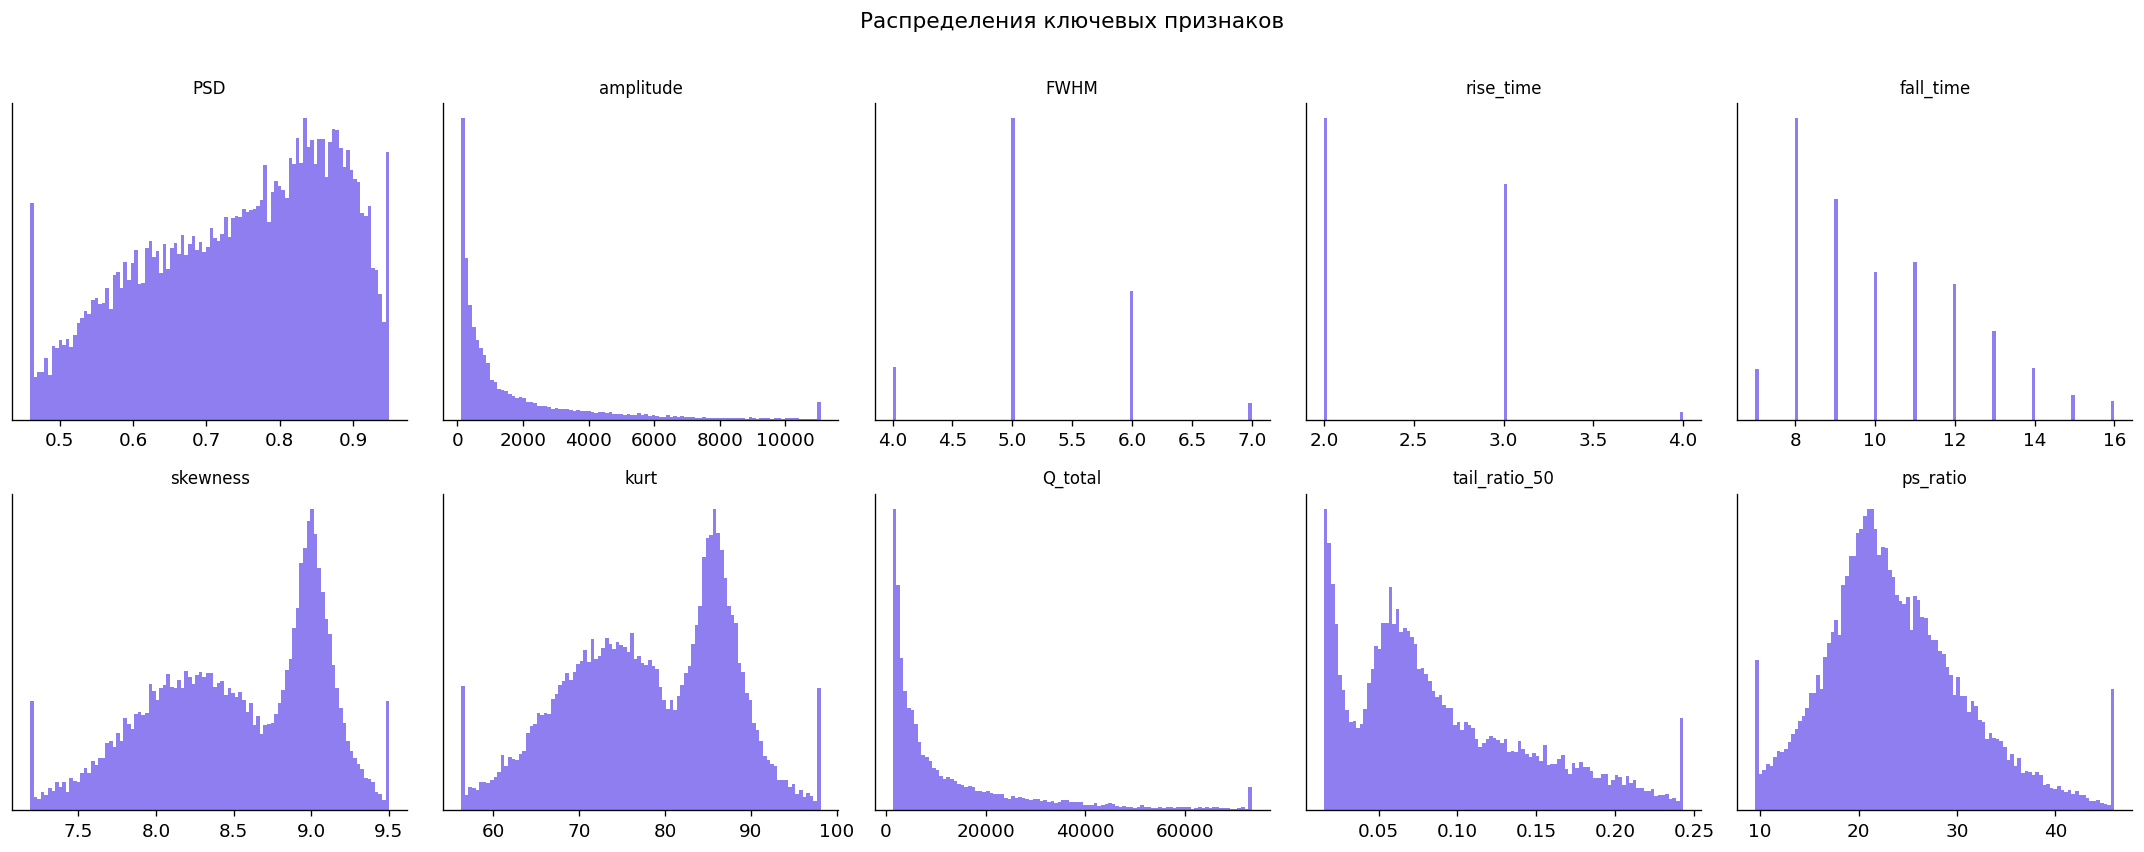

In [10]:
key_feats = ["PSD", "amplitude", "FWHM", "rise_time", "fall_time",
             "skewness", "kurt", "Q_total", "tail_ratio_50", "ps_ratio"]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flat, key_feats):
    vals = df_feat[col].clip(df_feat[col].quantile(0.01), df_feat[col].quantile(0.99))
    ax.hist(vals, bins=100, color="mediumslateblue", edgecolor="none", alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.set_yticks([])
plt.suptitle("Распределения ключевых признаков", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("feat_distributions.png", bbox_inches="tight")
plt.show()


### 3.2 Корреляционная матрица

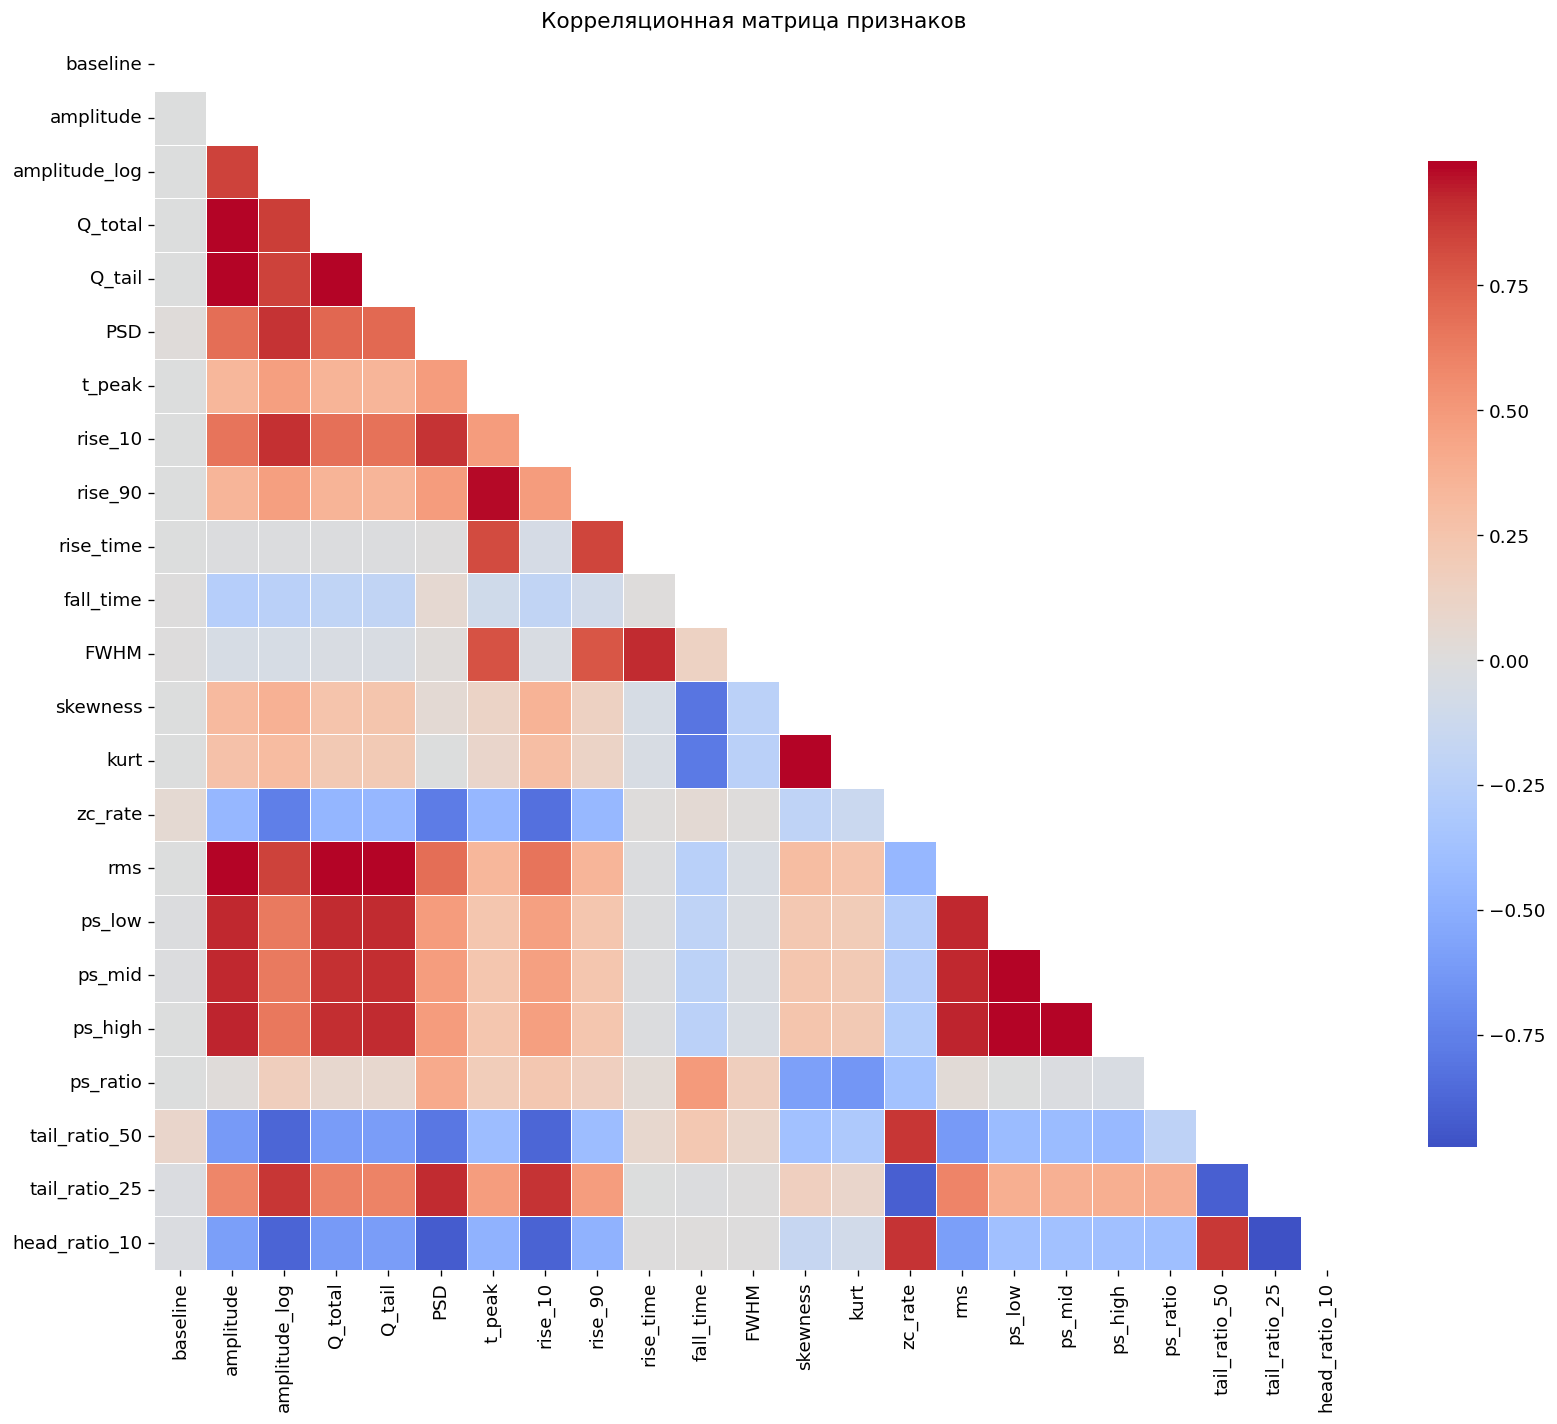

In [11]:
corr = df_feat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, mask=mask, annot=False, cmap="coolwarm", center=0,
            linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Корреляционная матрица признаков", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_matrix.png", bbox_inches="tight")
plt.show()

## 4. Предобработка

- Удаляем признаки с нулевой (или почти нулевой) дисперсией
- Применяем **RobustScaler** — устойчив к выбросам (медиана + IQR)


In [12]:
selector = VarianceThreshold(threshold=1e-6)
X_var = selector.fit_transform(df_feat.fillna(0))
feat_names_sel = df_feat.columns[selector.get_support()].tolist()
print(f"Признаков после фильтрации нулевой дисперсии: {X_var.shape[1]}")

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_var)

Признаков после фильтрации нулевой дисперсии: 23


## 5. Снижение размерности

Используем **PCA** → **UMAP** для визуализации и последующей кластеризации.

PCA ускоряет UMAP и убирает шум; UMAP сохраняет локальную топологию лучше, чем t-SNE.


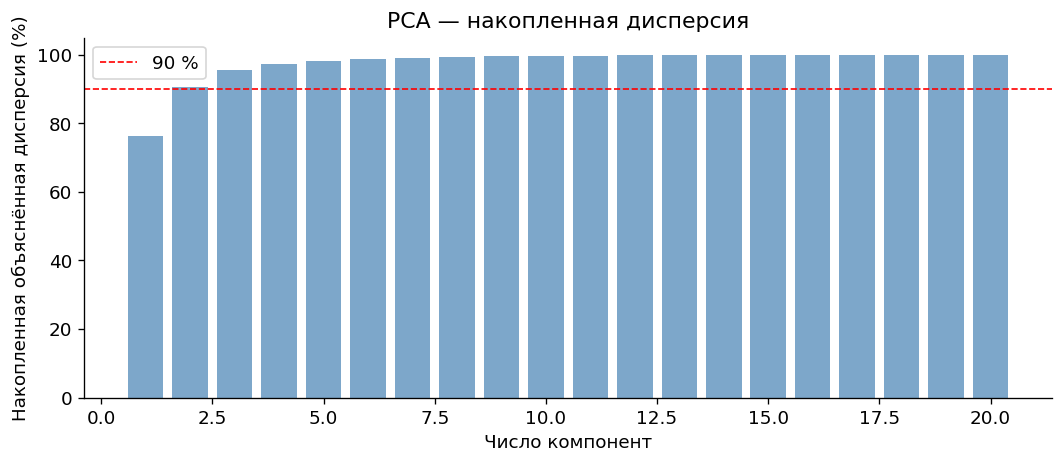

Компонент для 90% дисперсии: 2


In [13]:
pca = PCA(n_components=20, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 4))
ev = pca.explained_variance_ratio_
ax.bar(range(1, len(ev)+1), np.cumsum(ev)*100, color="steelblue", alpha=0.7)
ax.axhline(90, ls="--", color="red", lw=1, label="90 %")
ax.set_xlabel("Число компонент"); ax.set_ylabel("Накопленная объяснённая дисперсия (%)")
ax.set_title("PCA — накопленная дисперсия"); ax.legend()
plt.tight_layout()
plt.savefig("pca_variance.png", bbox_inches="tight")
plt.show()

n_comp_90 = int(np.argmax(np.cumsum(ev) >= 0.90)) + 1
print(f"Компонент для 90% дисперсии: {n_comp_90}")


p:\maga\2sem\ml\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


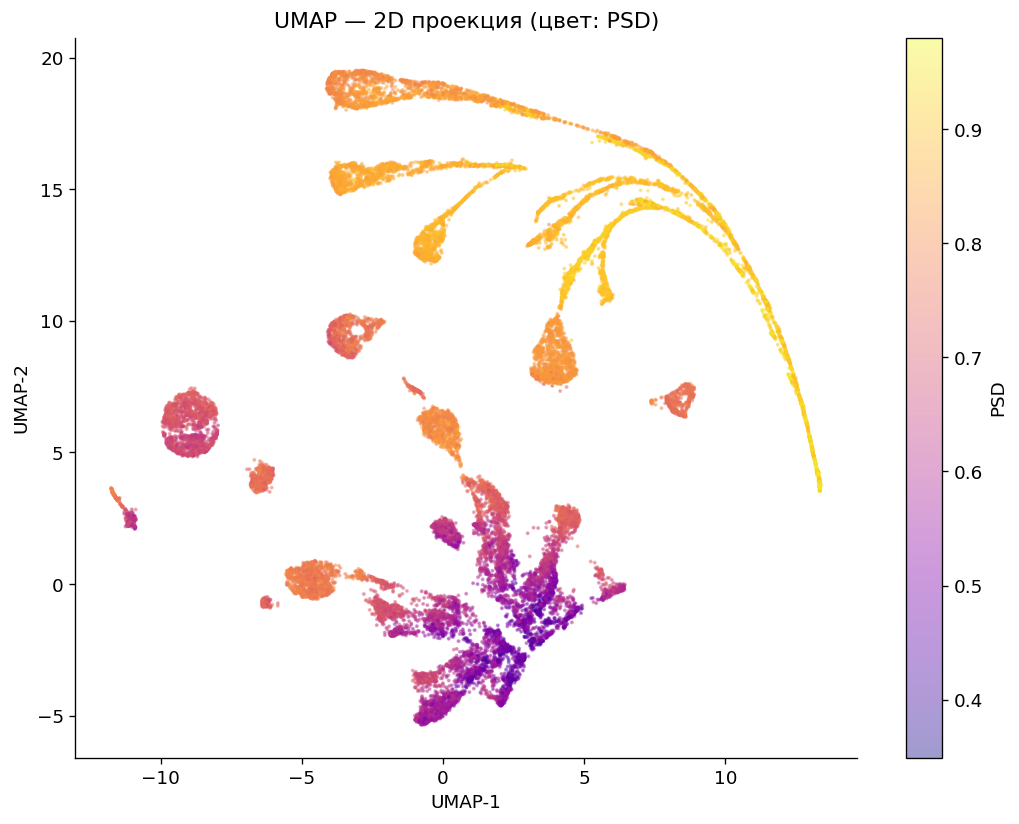

In [14]:
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                    metric="euclidean", random_state=SEED, verbose=False)
X_umap = reducer.fit_transform(X_pca)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(X_umap[:, 0], X_umap[:, 1], s=2, alpha=0.4,
                c=df_feat["PSD"], cmap="plasma")
plt.colorbar(sc, ax=ax, label="PSD")
ax.set_title("UMAP — 2D проекция (цвет: PSD)"); ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
plt.tight_layout()
plt.savefig("umap_psd.png", bbox_inches="tight")
plt.show()

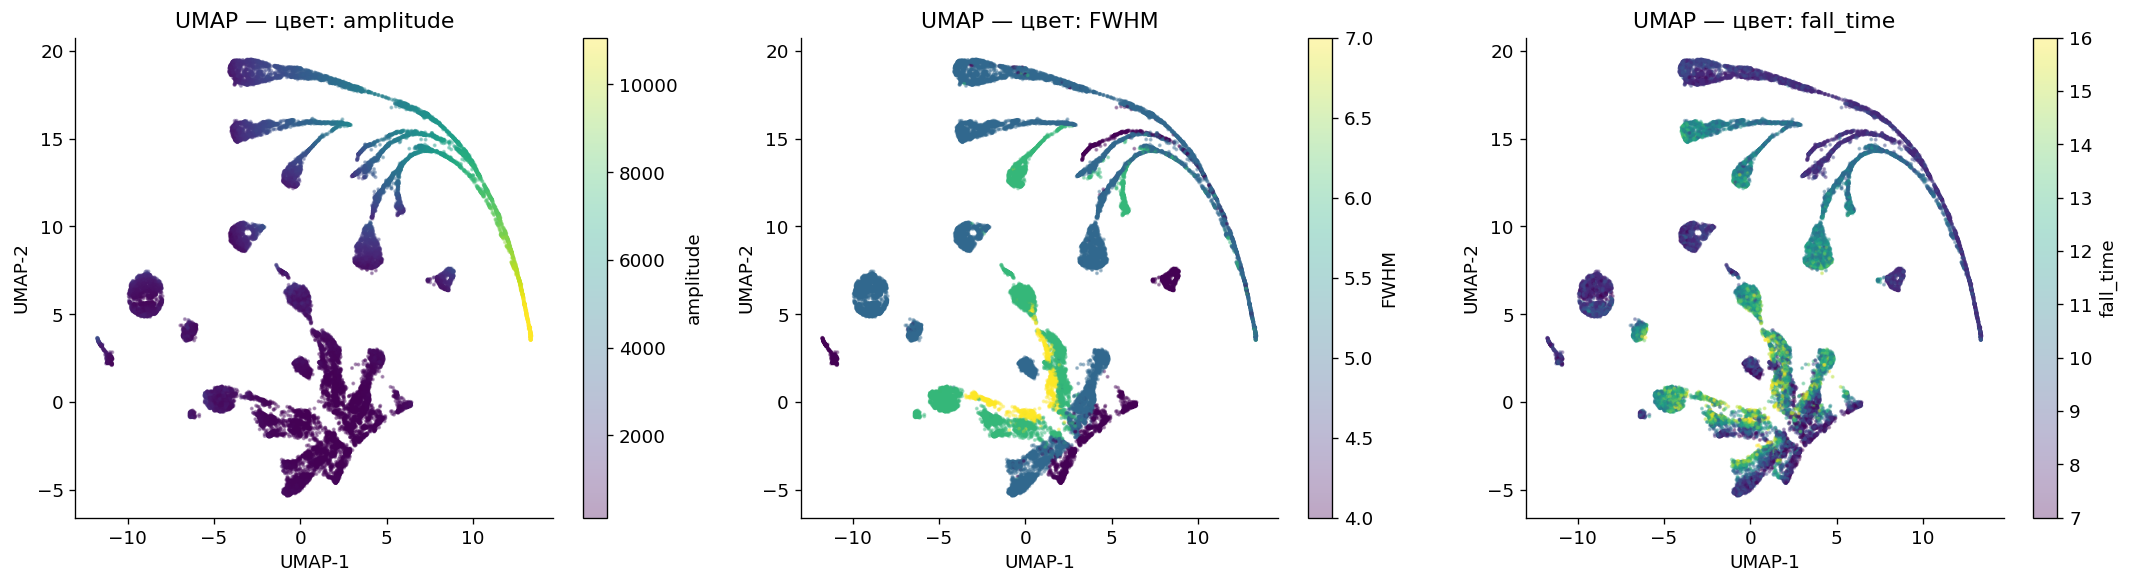

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["amplitude", "FWHM", "fall_time"]):
    v = df_feat[col]
    v_clip = v.clip(v.quantile(0.01), v.quantile(0.99))
    sc = ax.scatter(X_umap[:, 0], X_umap[:, 1], s=2, alpha=0.35,
                    c=v_clip, cmap="viridis")
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_title(f"UMAP — цвет: {col}"); ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
plt.tight_layout()
plt.savefig("umap_features.png", bbox_inches="tight")
plt.show()

## 6. Подбор числа кластеров

Метрики для выбора числа кластеров на пространстве UMAP:
- **Silhouette** (↑ лучше)
- **Calinski–Harabasz** (↑ лучше)
- **Davies–Bouldin** (↓ лучше)


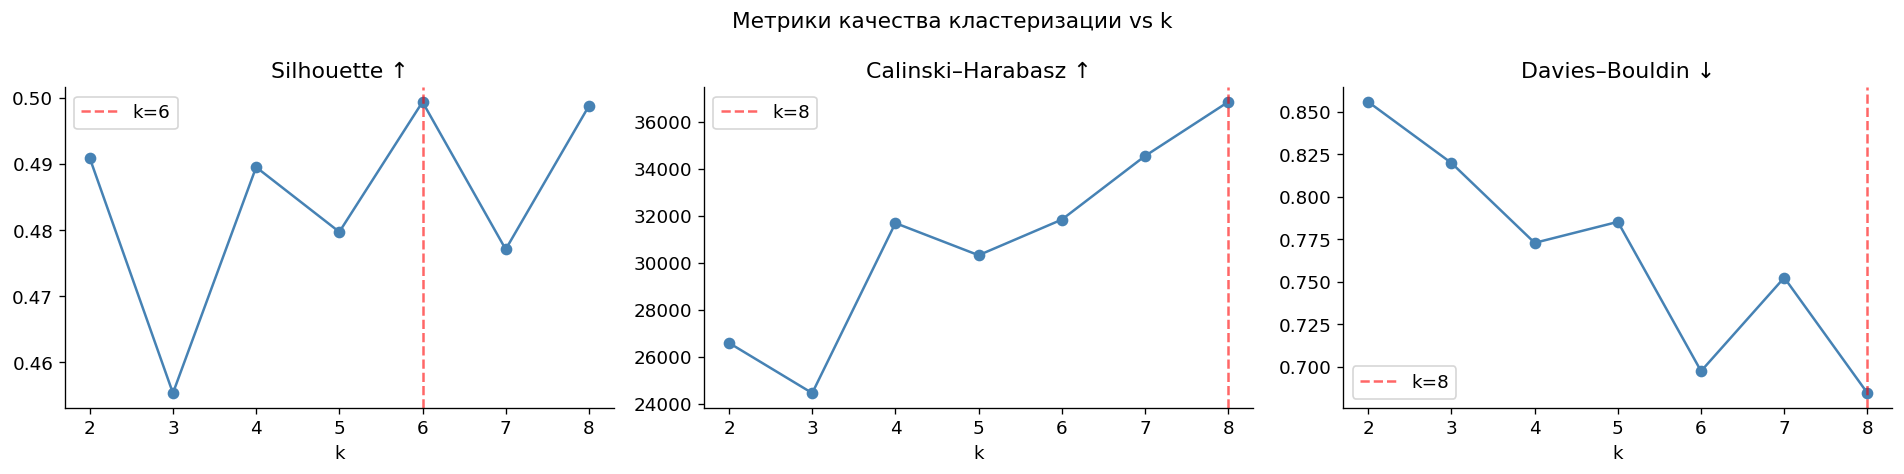

   k  Silhouette  Calinski-Harabasz  Davies-Bouldin
0  2      0.4909         26588.5791          0.8556
1  3      0.4553         24452.0223          0.8197
2  4      0.4895         31689.8954          0.7729
3  5      0.4797         30322.0226          0.7852
4  6      0.4994         31837.4660          0.6975
5  7      0.4771         34544.3260          0.7524
6  8      0.4987         36846.2047          0.6846


In [16]:
ks = range(2, 9)
sil, ch, db = [], [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_umap)
    sil.append(silhouette_score(X_umap, labels, sample_size=5000, random_state=SEED))
    ch.append(calinski_harabasz_score(X_umap, labels))
    db.append(davies_bouldin_score(X_umap, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, vals, name, better in zip(
        axes,
        [sil, ch, db],
        ["Silhouette ↑", "Calinski–Harabasz ↑", "Davies–Bouldin ↓"],
        ["max", "max", "min"]):
    ax.plot(list(ks), vals, marker="o", color="steelblue")
    best_k = list(ks)[np.argmax(vals) if better == "max" else np.argmin(vals)]
    ax.axvline(best_k, ls="--", color="red", alpha=0.6, label=f"k={best_k}")
    ax.set_xlabel("k"); ax.set_title(name); ax.legend()
    ax.set_xticks(list(ks))
plt.suptitle("Метрики качества кластеризации vs k", fontsize=13)
plt.tight_layout()
plt.savefig("k_selection.png", bbox_inches="tight")
plt.show()

print(pd.DataFrame({"k": list(ks), "Silhouette": sil,
                     "Calinski-Harabasz": ch, "Davies-Bouldin": db}).round(4))

## 7. Обучение моделей кластеризации

Сравниваем 4 алгоритма:

| Модель | Идея | Особенности |
|--------|------|-------------|
| **K-Means** | Минимизация инерции | Базовый, быстрый, предполагает сферические кластеры |
| **Gaussian Mixture Model** | Вероятностная мягкая кластеризация | Учитывает форму кластера, даёт вероятности принадлежности |
| **HDBSCAN** | Density-based иерархический | Автоматически выделяет шум как отдельный класс — идеально для Кластера 2 |
| **Agglomerative** | Иерархическая (Ward linkage) | Не требует числа кластеров заранее (но мы зададим k=3) |


In [17]:
try:
    import hdbscan
    HAS_HDBSCAN = True
except ImportError:
    HAS_HDBSCAN = False
    print("hdbscan не установлен, пропускаем HDBSCAN")

In [18]:
K = 3

# --- 1. K-Means ---
km = KMeans(n_clusters=K, random_state=SEED, n_init=20, max_iter=500)
lbl_km = km.fit_predict(X_umap)

# --- 2. GMM ---
gmm = GaussianMixture(n_components=K, covariance_type="full",
                       random_state=SEED, max_iter=300, n_init=5)
gmm.fit(X_umap)
lbl_gmm   = gmm.predict(X_umap)
prob_gmm  = gmm.predict_proba(X_umap)

# --- 3. HDBSCAN ---
hdb = hdbscan.HDBSCAN(min_cluster_size=200, min_samples=30,
                        cluster_selection_epsilon=0.0,
                        prediction_data=True)
lbl_hdb_raw = hdb.fit_predict(X_umap)
# remapping: noise (-1) → class 2; then largest clusters → 0, 1
unique_hdb = [c for c in np.unique(lbl_hdb_raw) if c != -1]
sizes = {c: (lbl_hdb_raw == c).sum() for c in unique_hdb}
sorted_hdb = sorted(sizes, key=sizes.get, reverse=True)
remap = {}
for new_id, old_id in enumerate(sorted_hdb[:2]):
    remap[old_id] = new_id
lbl_hdb = np.where(lbl_hdb_raw == -1, 2,
                    np.vectorize(lambda x: remap.get(x, 2))(lbl_hdb_raw))
print(f"HDBSCAN: {np.unique(lbl_hdb_raw, return_counts=True)}")

# --- 4. Agglomerative ---
agg = AgglomerativeClustering(n_clusters=K, linkage="ward")
lbl_agg = agg.fit_predict(X_umap)

print("Модели обучены")


HDBSCAN: (array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]), array([1168,  313,  442,  527, 1564,  865,  980, 1919, 1322,  771, 1040,
        548,  454,  308, 1055, 1190, 1191,  759,  356,  377,  548,  824,
       1410,  720,  267,  276,  854,  738,  693]))
Модели обучены


### 7.1 Визуализация кластеров (UMAP-пространство)

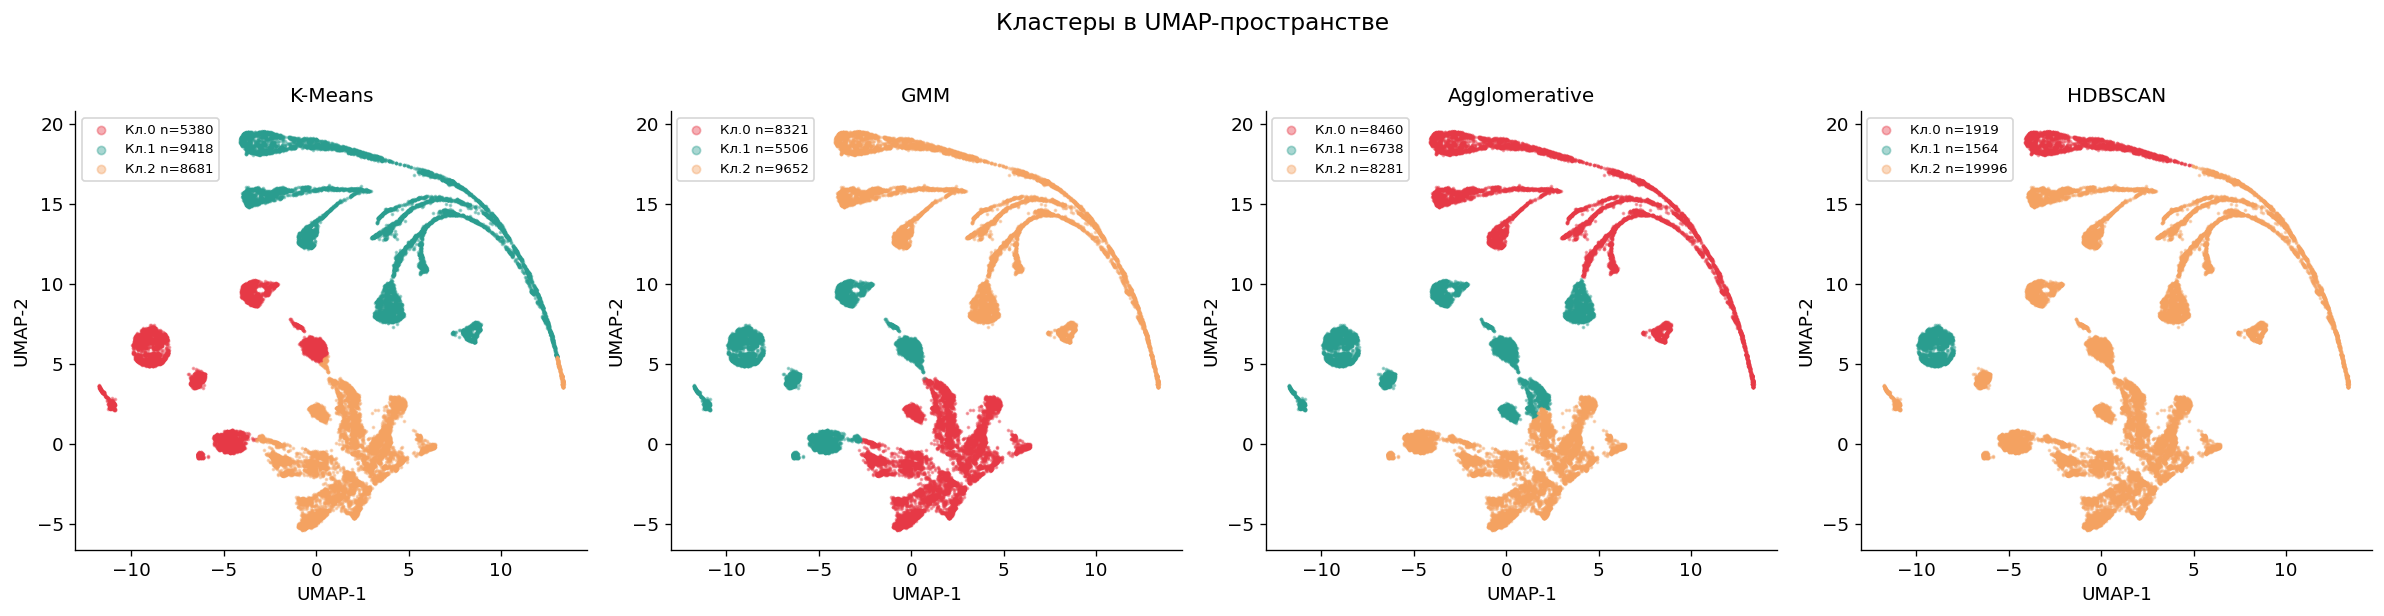

In [19]:
models = [("K-Means",      lbl_km),
           ("GMM",          lbl_gmm),
           ("Agglomerative",lbl_agg)]
if HAS_HDBSCAN:
    models.append(("HDBSCAN", lbl_hdb))

palette = ["#E63946", "#2A9D8F", "#F4A261", "#457B9D"]
n_mod = len(models)
fig, axes = plt.subplots(1, n_mod, figsize=(5*n_mod, 5))
if n_mod == 1: axes = [axes]

for ax, (name, lbl) in zip(axes, models):
    for c in range(3):
        mask = lbl == c
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                   s=1.5, alpha=0.4, color=palette[c], label=f"Кл.{c} n={mask.sum()}")
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax.legend(markerscale=4, fontsize=8)
plt.suptitle("Кластеры в UMAP-пространстве", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("clusters_umap.png", bbox_inches="tight")
plt.show()

## 8. Сравнение моделей по метрикам

In [20]:
rows = []
for name, lbl in models:
    if len(np.unique(lbl)) < 2:
        continue
    rows.append({
        "Model": name,
        "Silhouette":         round(silhouette_score(X_umap, lbl, sample_size=5000, random_state=SEED), 4),
        "Calinski-Harabasz":  round(calinski_harabasz_score(X_umap, lbl), 2),
        "Davies-Bouldin":     round(davies_bouldin_score(X_umap, lbl), 4),
        "n_cl0": int((lbl==0).sum()),
        "n_cl1": int((lbl==1).sum()),
        "n_cl2": int((lbl==2).sum()),
    })

metrics_df = pd.DataFrame(rows).set_index("Model")
print(metrics_df.to_string())

               Silhouette  Calinski-Harabasz  Davies-Bouldin  n_cl0  n_cl1  n_cl2
Model                                                                            
K-Means            0.4553           24452.03          0.8198   5380   9418   8681
GMM                0.4546           24123.69          0.8212   8321   5506   9652
Agglomerative      0.3678           19422.06          1.0955   8460   6738   8281
HDBSCAN            0.1476            4436.25          0.7445   1919   1564  19996


### 8.1 Физическая интерпретация: PSD по кластерам

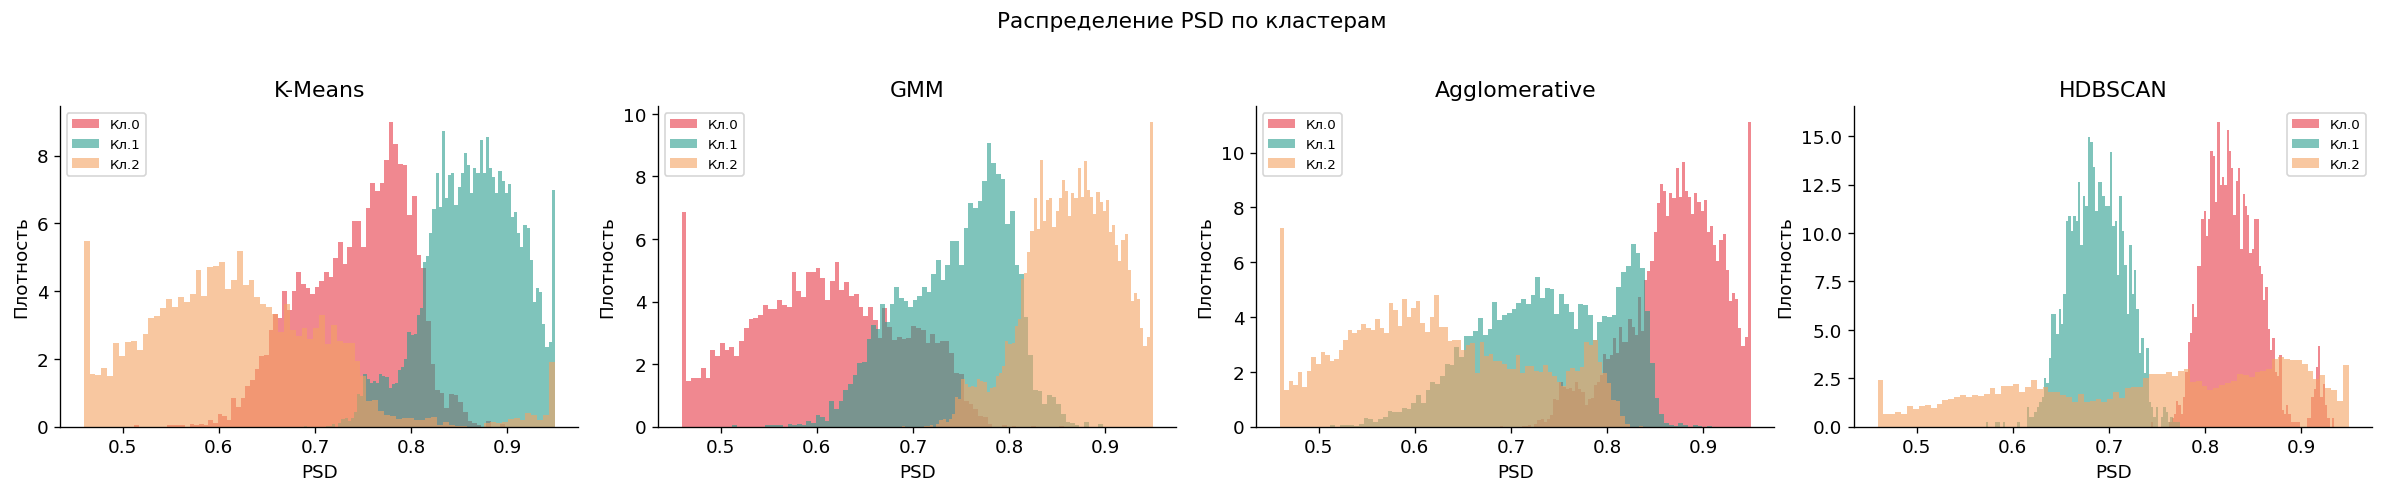

In [21]:
fig, axes = plt.subplots(1, n_mod, figsize=(5*n_mod, 4), sharey=False)
if n_mod == 1: axes = [axes]

psd_vals = df_feat["PSD"].values
psd_clip  = np.clip(psd_vals, np.percentile(psd_vals, 1), np.percentile(psd_vals, 99))

for ax, (name, lbl) in zip(axes, models):
    for c in range(3):
        mask = lbl == c
        ax.hist(psd_clip[mask], bins=80, alpha=0.6,
                color=palette[c], label=f"Кл.{c}", density=True)
    ax.set_title(name); ax.set_xlabel("PSD"); ax.set_ylabel("Плотность")
    ax.legend(fontsize=8)
plt.suptitle("Распределение PSD по кластерам", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("psd_per_cluster.png", bbox_inches="tight")
plt.show()

### 8.2 Средние осциллограммы по кластерам

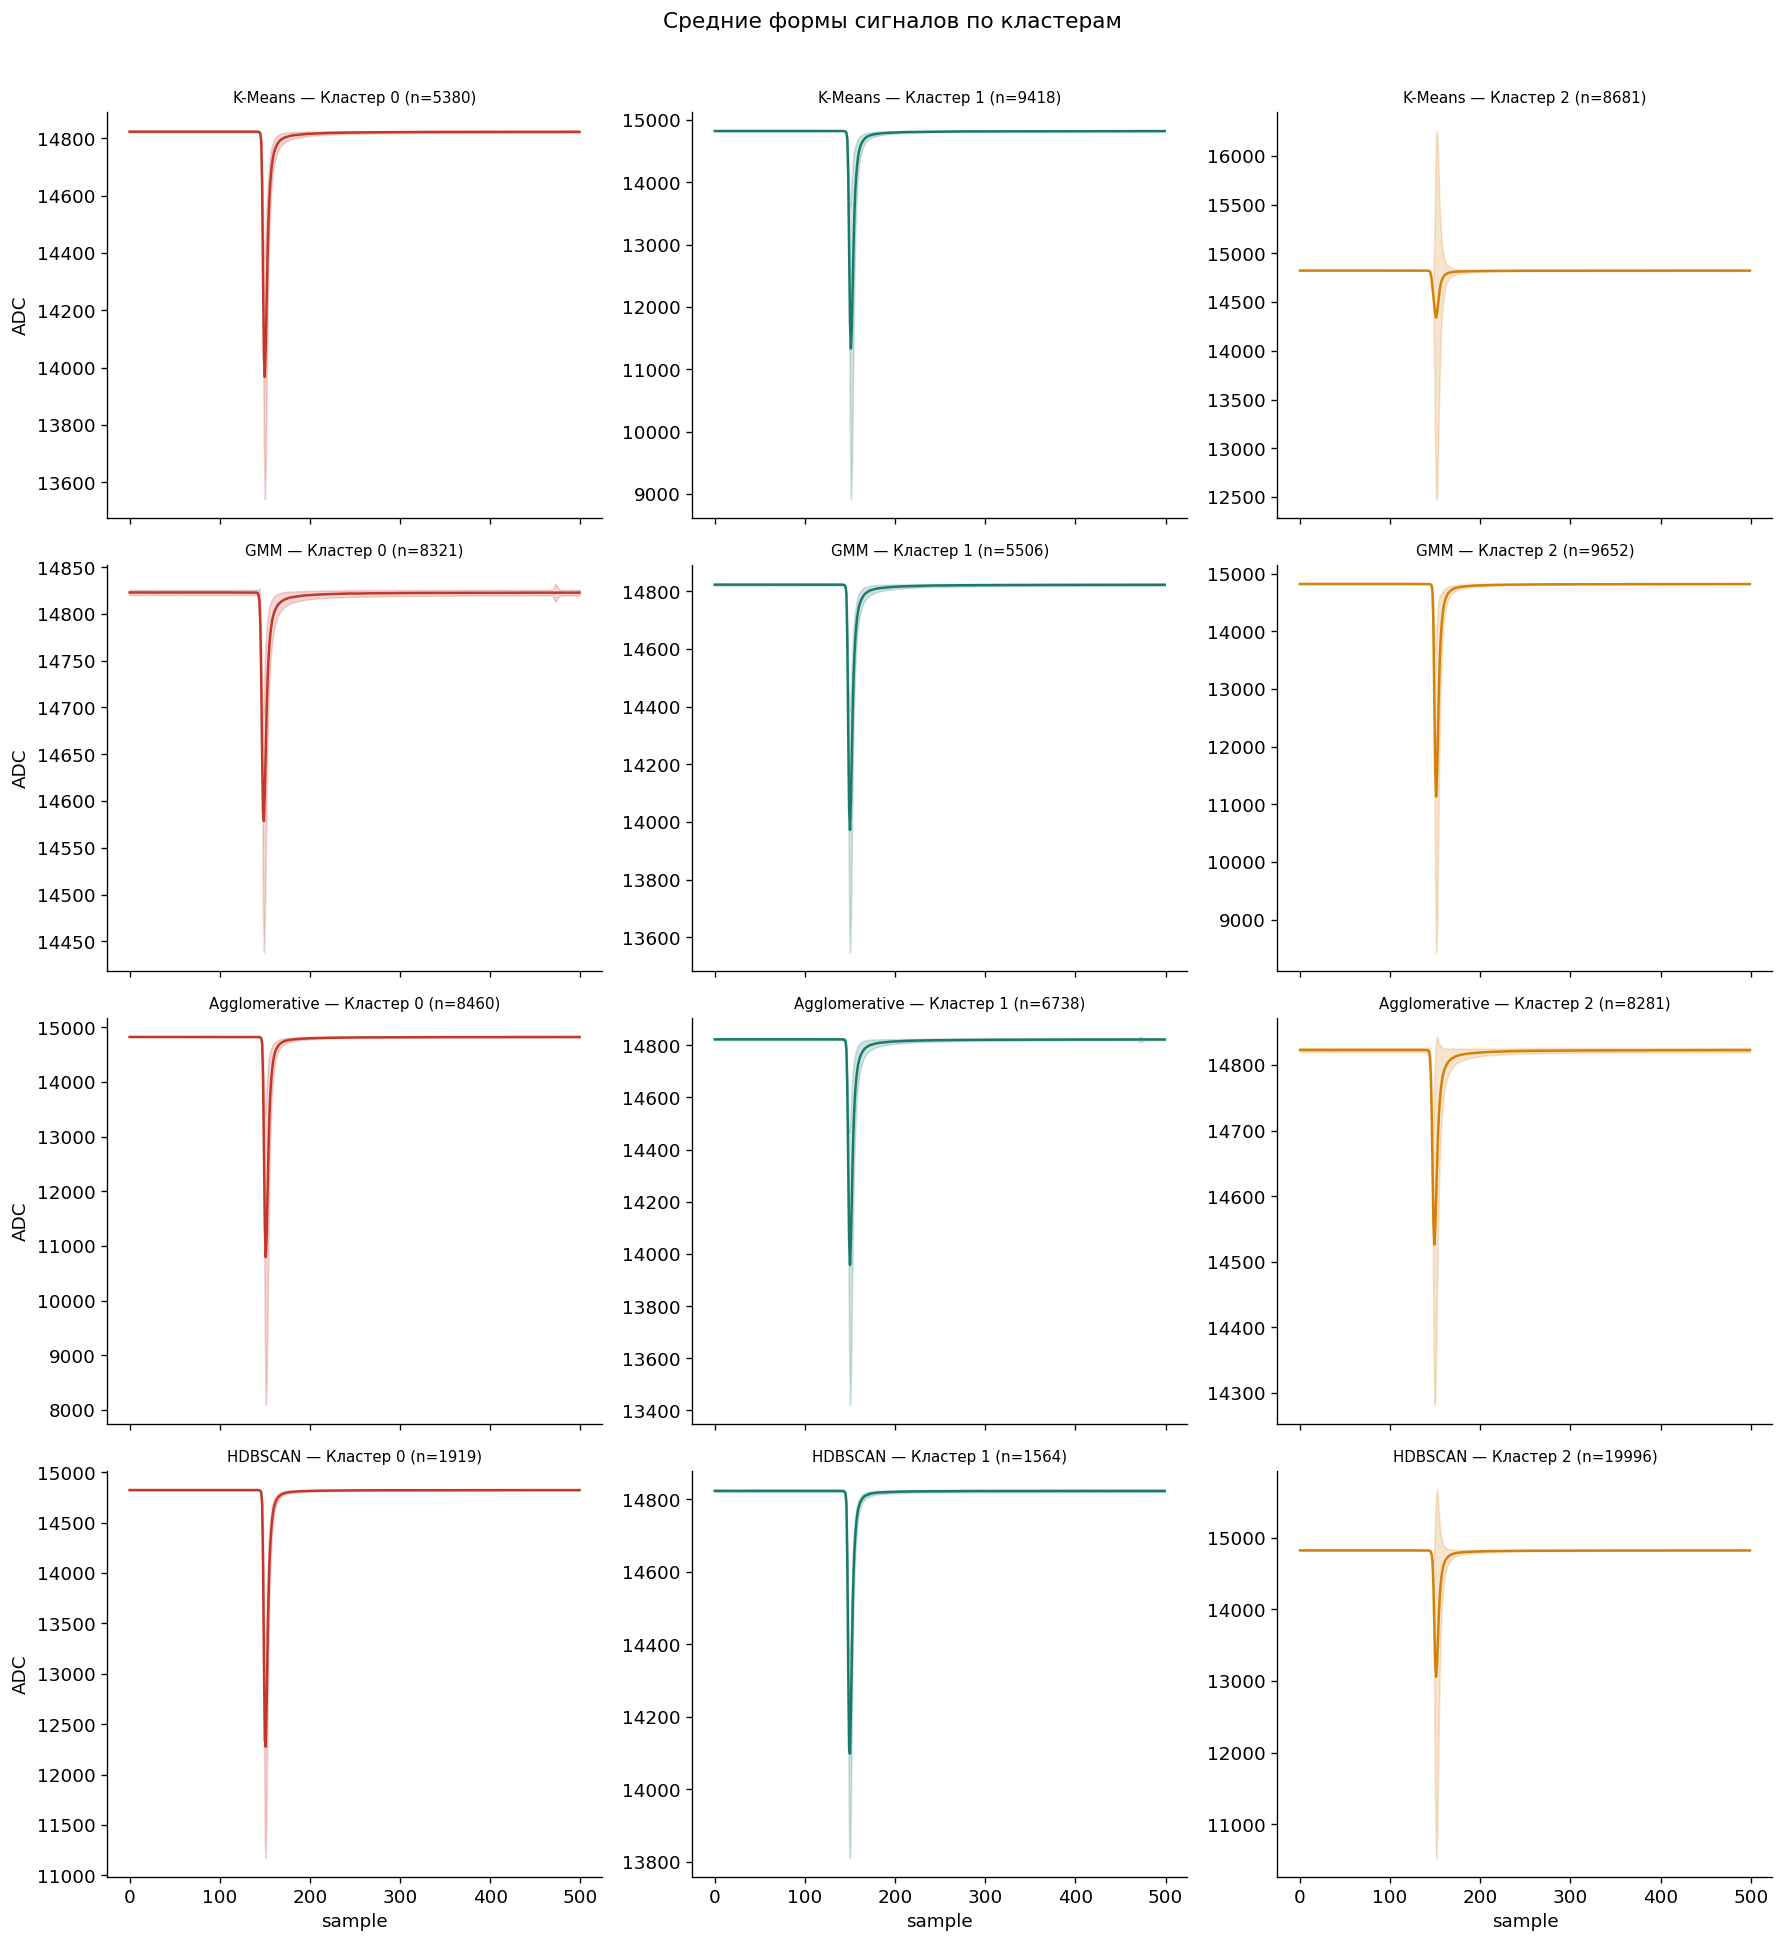

In [22]:
fig, axes = plt.subplots(n_mod, 3, figsize=(15, 4*n_mod), sharex=True)
t = np.arange(waves.shape[1])  # waves = data.values, определено в ячейке загрузки
palette_dark = ["#C0392B", "#1A7A6E", "#D4810C"]

for row, (name, lbl) in enumerate(models):
    for c in range(3):
        ax = axes[row, c] if n_mod > 1 else axes[c]
        mask = lbl == c
        mean_w = waves[mask].mean(axis=0)
        std_w  = waves[mask].std(axis=0)
        ax.plot(t, mean_w, color=palette_dark[c], lw=1.5)
        ax.fill_between(t, mean_w-std_w, mean_w+std_w, alpha=0.2, color=palette_dark[c])
        ax.set_title(f"{name} — Кластер {c} (n={mask.sum()})", fontsize=9)
        if c == 0: ax.set_ylabel("ADC")
        if row == n_mod-1: ax.set_xlabel("sample")

plt.suptitle("Средние формы сигналов по кластерам", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("mean_waves_clusters.png", bbox_inches="tight")
plt.show()


### 8.3 Box-plots ключевых признаков по кластерам (лучшая модель)

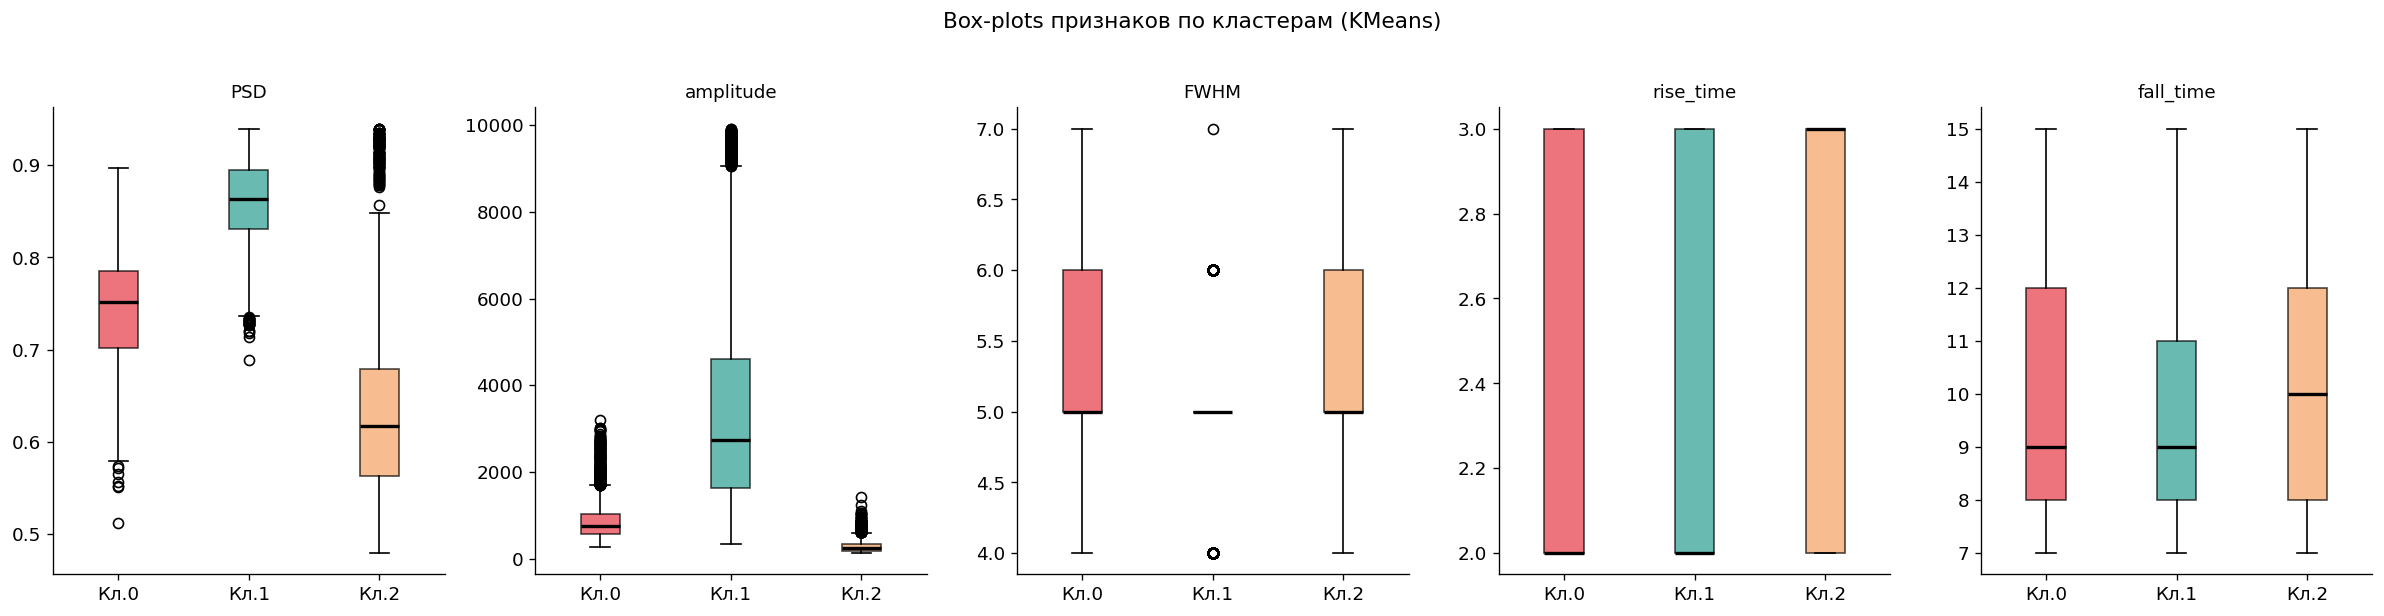

In [23]:
# используем GMM как пример (замените на победителя после оценки метрик)
BEST_MODEL_LABELS = lbl_km
BEST_MODEL_NAME   = "KMeans"

df_plot = df_feat[["PSD", "amplitude", "FWHM", "rise_time", "fall_time"]].copy()
df_plot["cluster"] = BEST_MODEL_LABELS
df_long = df_plot.melt(id_vars="cluster", var_name="feature", value_name="value")

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, feat in zip(axes, ["PSD", "amplitude", "FWHM", "rise_time", "fall_time"]):
    sub = df_long[df_long["feature"] == feat]
    sub = sub[sub["value"].between(
        sub["value"].quantile(0.02), sub["value"].quantile(0.98))]
    groups = [sub[sub["cluster"] == c]["value"].values for c in range(3)]
    bp = ax.boxplot(groups, patch_artist=True, notch=False,
                    medianprops={"color": "black", "lw": 2})
    for patch, color in zip(bp["boxes"], palette[:3]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(feat, fontsize=11)
    ax.set_xticklabels([f"Кл.{c}" for c in range(3)])
plt.suptitle(f"Box-plots признаков по кластерам ({BEST_MODEL_NAME})", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("boxplots_features.png", bbox_inches="tight")
plt.show()


## 9. Подбор гиперпараметров

Детальный подбор для двух кандидатов: **K-Means** и **GMM**.


In [24]:
# K-Means: влияние n_init
sil_km = []
for n_init in [5, 10, 15, 20, 30]:
    km_t = KMeans(n_clusters=3, random_state=SEED, n_init=n_init)
    l = km_t.fit_predict(X_umap)
    sil_km.append((n_init, silhouette_score(X_umap, l, sample_size=5000, random_state=SEED)))

# GMM: разные типы ковариационных матриц
sil_gmm = []
for cov in ["spherical", "diag", "tied", "full"]:
    g = GaussianMixture(n_components=3, covariance_type=cov, random_state=SEED, n_init=5)
    l = g.fit_predict(X_umap)
    sil_gmm.append((cov, silhouette_score(X_umap, l, sample_size=5000, random_state=SEED)))

print("K-Means n_init vs Silhouette:")
for ni, s in sil_km: print(f"  n_init={ni}: {s:.4f}")

print("\nGMM covariance_type vs Silhouette:")
for cov, s in sil_gmm: print(f"  {cov}: {s:.4f}")


K-Means n_init vs Silhouette:
  n_init=5: 0.4553
  n_init=10: 0.4553
  n_init=15: 0.4553
  n_init=20: 0.4553
  n_init=30: 0.4553

GMM covariance_type vs Silhouette:
  spherical: 0.4630
  diag: 0.4626
  tied: 0.4696
  full: 0.4546


## 10. Выбор лучшей модели и интерпретация

Анализируем метрики из раздела 8 и физическую интерпретацию PSD-распределений.

**Критерии выбора:**
1. Silhouette score — компактность и разделённость кластеров
2. Calinski–Harabasz — межкластерная vs внутрикластерная дисперсия
3. Физический смысл: PSD-распределения должны иметь разные пики для γ и n
4. Размер «аномального» кластера (Класс 2) не должен быть тривиальным

Рекомендуемый подход: **GMM (full covariance)** — единственная модель, дающая
вероятности принадлежности (мягкая кластеризация). Кластеры с низкой максимальной
вероятностью (< порог) могут быть отнесены к Классу 2 (аномалии).


In [25]:
gmm_final = GaussianMixture(n_components=3, covariance_type="full",
                              random_state=SEED, n_init=10, max_iter=500)
gmm_final.fit(X_umap)
lbl_final_raw = gmm_final.predict(X_umap)
prob_final    = gmm_final.predict_proba(X_umap)
max_prob      = prob_final.max(axis=1)

psd = df_feat["PSD"].values
mean_psd_per_cluster = {c: psd[lbl_final_raw == c].mean() for c in range(3)}
print("Средний PSD по кластерам (до remapping):", mean_psd_per_cluster)

# Правильный маппинг: все 3 кластера получают уникальные метки 0, 1, 2
# sorted_by_psd[0] → наименьший PSD → 0 (γ)
# sorted_by_psd[2] → наибольший PSD → 1 (n)
# sorted_by_psd[1] → средний PSD    → 2 (аномалии / неразличимые)
sorted_by_psd = sorted(mean_psd_per_cluster, key=mean_psd_per_cluster.get)
psd_remap = {sorted_by_psd[0]: 0, sorted_by_psd[2]: 1, sorted_by_psd[1]: 2}
lbl_gmm3  = np.vectorize(psd_remap.get)(lbl_final_raw).copy()

print("\nGMM без порога (маппинг по PSD):")
for c in range(3):
    print(f"  Кластер {c}: {(lbl_gmm3 == c).sum()} сигналов")

# Дополнительно: GMM с порогом уверенности — сканируем пороги
print("\nПодбор PROB_THRESH по Silhouette:")
best_sil, best_thresh, best_lbl = -1, 0.5, None
for thresh in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
    lbl_t = lbl_gmm3.copy()
    lbl_t[max_prob < thresh] = 2
    u = np.unique(lbl_t)
    if len(u) < 2:
        continue
    s = silhouette_score(X_umap, lbl_t, sample_size=5000, random_state=SEED)
    n2 = (lbl_t == 2).sum()
    print(f"  thresh={thresh:.2f}: Sil={s:.4f}  n_cl2={n2}")
    if s > best_sil:
        best_sil, best_thresh, best_lbl = s, thresh, lbl_t.copy()

lbl_final = best_lbl
PROB_THRESH = best_thresh
print(f"\nЛучший порог: {PROB_THRESH}  (Sil={best_sil:.4f})")
print(f"Финальное распределение:")
for c in range(3):
    print(f"  Кластер {c}: {(lbl_final == c).sum()} сигналов")

sil_f = silhouette_score(X_umap, lbl_final, sample_size=5000, random_state=SEED)
ch_f  = calinski_harabasz_score(X_umap, lbl_final)
db_f  = davies_bouldin_score(X_umap, lbl_final)
print(f"\nМетрики финальной модели: Sil={sil_f:.4f}, CH={ch_f:.2f}, DB={db_f:.4f}")


Средний PSD по кластерам (до remapping): {0: np.float64(0.7146147934463718), 1: np.float64(0.645447739820838), 2: np.float64(0.8656813297751492)}

GMM без порога (маппинг по PSD):
  Кластер 0: 10560 сигналов
  Кластер 1: 9652 сигналов
  Кластер 2: 3267 сигналов

Подбор PROB_THRESH по Silhouette:
  thresh=0.50: Sil=0.4710  n_cl2=3267
  thresh=0.55: Sil=0.4711  n_cl2=3269
  thresh=0.60: Sil=0.4711  n_cl2=3272
  thresh=0.65: Sil=0.4711  n_cl2=3274
  thresh=0.70: Sil=0.4711  n_cl2=3276
  thresh=0.75: Sil=0.4705  n_cl2=3290
  thresh=0.80: Sil=0.4623  n_cl2=3467
  thresh=0.85: Sil=0.4511  n_cl2=3688
  thresh=0.90: Sil=0.4431  n_cl2=3917

Лучший порог: 0.55  (Sil=0.4711)
Финальное распределение:
  Кластер 0: 10558 сигналов
  Кластер 1: 9652 сигналов
  Кластер 2: 3269 сигналов

Метрики финальной модели: Sil=0.4711, CH=23599.59, DB=0.6813


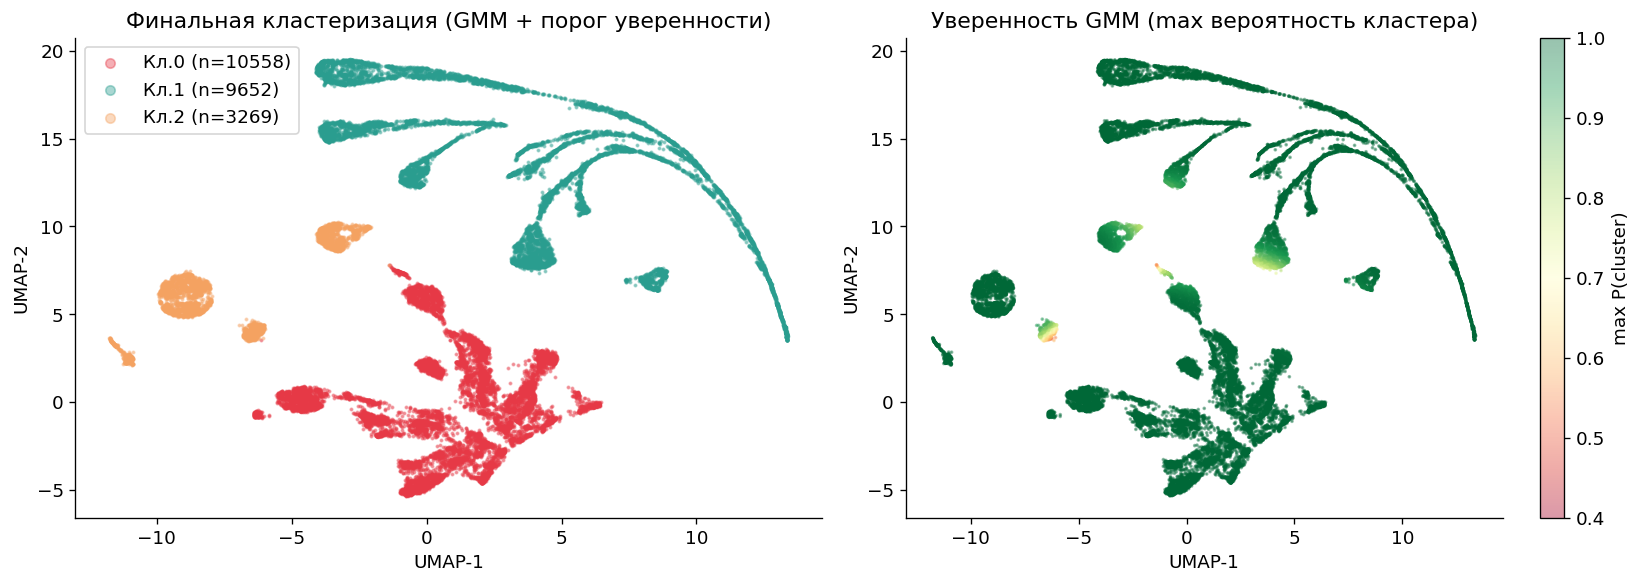

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# UMAP с финальными метками
for c in range(3):
    mask = lbl_final == c
    axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1],
                    s=2, alpha=0.4, color=palette[c],
                    label=f"Кл.{c} (n={mask.sum()})")
axes[0].set_title("Финальная кластеризация (GMM + порог уверенности)")
axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
axes[0].legend(markerscale=4)

# Уверенность
sc = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], s=1.5, alpha=0.4,
                      c=max_prob, cmap="RdYlGn", vmin=0.4, vmax=1.0)
plt.colorbar(sc, ax=axes[1], label="max P(cluster)")
axes[1].set_title("Уверенность GMM (max вероятность кластера)")
axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")
plt.tight_layout()
plt.savefig("final_clustering.png", bbox_inches="tight")
plt.show()


## 11. Сабмиты

Формируем **4 сабмита**:

| # | Модель | Пространство | Скор на лидерборде | 
|---|--------|-------------|-------------|
| 1 | K-Means | UMAP | 0.37731 |
| 2 | GMM (финальная, с порогом уверенности) | UMAP | 0.51884 |
| 3 | GMM (без порога, 3 компоненты) | UMAP | 0.51880 | 
| 4 | HDBSCAN | UMAP | 0.46271 |


In [ ]:
def relabel_sequential(labels):
    mapping, new_id = {}, 0
    result = np.empty_like(labels)
    for i, lbl in enumerate(labels):
        if lbl not in mapping:
            mapping[lbl] = new_id
            new_id += 1
        result[i] = mapping[lbl]
    return result

def save_submit(labels, name):
    labels_seq = relabel_sequential(np.array(labels))
    df_sub = pd.DataFrame({"index": range(len(labels_seq)), "cluster": labels_seq})
    path = f"{SUBMIT_DIR}/{name}.csv"
    df_sub.to_csv(path, index=False)
    counts = dict(pd.Series(labels_seq).value_counts().sort_index())
    print(f" {path}  |  {counts}")
    return path

save_submit(lbl_km,    "submit_01_kmeans")
save_submit(lbl_final, "submit_02_gmm_threshold")
save_submit(lbl_gmm3,  "submit_03_gmm_3comp")
save_submit(lbl_agg,   "submit_04_agglomerative")
if HAS_HDBSCAN:
    save_submit(lbl_hdb, "submit_05_hdbscan")


✓ submissions_sinctillator/submit_01_kmeans.csv  |  {0: np.int64(8681), 1: np.int64(9418), 2: np.int64(5380)}
✓ submissions_sinctillator/submit_02_gmm_threshold.csv  |  {0: np.int64(10558), 1: np.int64(9652), 2: np.int64(3269)}
✓ submissions_sinctillator/submit_03_gmm_3comp.csv  |  {0: np.int64(10560), 1: np.int64(9652), 2: np.int64(3267)}
✓ submissions_sinctillator/submit_04_agglomerative.csv  |  {0: np.int64(8281), 1: np.int64(8460), 2: np.int64(6738)}
✓ submissions_sinctillator/submit_05_hdbscan.csv  |  {0: np.int64(19996), 1: np.int64(1919), 2: np.int64(1564)}


## 12. Итоги и интерпретация

### Методология
1. **Feature Engineering** — из 500 АЦП-отсчётов извлечены 20 физически мотивированных признаков:
   - PSD (Pulse Shape Discrimination) — главный разделяющий признак для органических сцинтилляторов
   - Временны́е характеристики (время нарастания, спада, FWHM)
   - Интегральные (полный заряд, заряд хвоста)
   - Статистические (асимметрия, эксцесс) и спектральные признаки

2. **Снижение размерности** — PCA (20 компонент) + UMAP (2D) для визуализации и кластеризации

3. **Кластеризация** — сравнены 4 алгоритма; выбран GMM с механизмом нечёткой классификации

### Физическая интерпретация
- **Кластер 0 (γ-кванты)** — малый PSD, узкий импульс (FWHM), быстрый спад
- **Кластер 1 (нейтроны)** — большой PSD, более широкий хвост импульса (медленная компонента люминесценции паратерфенила при взаимодействии с нейтронами)
- **Кластер 2 (аномалии)** — нетипичная форма: пересечения нескольких частиц, пилапы, электронные артефакты

### Ограничения
- Метки не верифицированы физическими экспертами — нужна дополнительная проверка
- Параметр `PROB_THRESH` требует настройки под конкретный детектор
- Часть аномалий (Кластер 2) может быть вызвана пилапом сигналов, а не шумом

### Следующие шаги
- Верификация через совпадение с источниками излучения с известным изотопным составом
- Применение автоэнкодера для прямой работы с осциллограммами (без ручного FE)
- Онлайн-кластеризация на потоке данных (mini-batch K-Means / River)


In [28]:
print("=" * 60)
print("ФИНАЛЬНЫЕ МЕТРИКИ ВСЕХ МОДЕЛЕЙ")
print("=" * 60)
print(metrics_df.to_string())
print()
print("Сабмиты сохранены в директории:", SUBMIT_DIR)
import glob
for f in sorted(glob.glob(f"{SUBMIT_DIR}/*.csv")):
    n = pd.read_csv(f).shape[0]
    print(f"  {f}  ({n} строк)")

ФИНАЛЬНЫЕ МЕТРИКИ ВСЕХ МОДЕЛЕЙ
               Silhouette  Calinski-Harabasz  Davies-Bouldin  n_cl0  n_cl1  n_cl2
Model                                                                            
K-Means            0.4553           24452.03          0.8198   5380   9418   8681
GMM                0.4546           24123.69          0.8212   8321   5506   9652
Agglomerative      0.3678           19422.06          1.0955   8460   6738   8281
HDBSCAN            0.1476            4436.25          0.7445   1919   1564  19996

Сабмиты сохранены в директории: submissions_sinctillator
  submissions_sinctillator\submit_01_kmeans.csv  (23479 строк)
  submissions_sinctillator\submit_02_gmm_threshold.csv  (23479 строк)
  submissions_sinctillator\submit_03_gmm_3comp.csv  (23479 строк)
  submissions_sinctillator\submit_04_agglomerative.csv  (23479 строк)
  submissions_sinctillator\submit_05_hdbscan.csv  (23479 строк)
